In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/atilsamancioglu/MachineLearningNotebooks/refs/heads/main/16-diabetes.csv')

In [3]:
df.head() # iş gerektiren bir data biraz temizlenmesi gerek

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.info() #boş yok, typelar da düzgün (encoding ile uğraşmayacağız)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.describe() #bazı yerlerin min 0 burada hata olabilir

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [7]:
df.Insulin.value_counts() # sıfır insulin olmaz

,count
Insulin,
0,374
105,11
130,9
140,9
120,8
...,...
178,1
127,1
510,1


In [8]:
df.BloodPressure.value_counts()

,count
BloodPressure,
70,57
74,52
78,45
68,45
72,44
64,43
80,40
76,39
60,37


In [9]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [10]:
# Check columns
# aşağıdakilerin % kaçı sıfır
columns_to_check = ['Glucose', 'BloodPressure','SkinThickness', 'Insulin', 'BMI']

for col in columns_to_check:
  zero_count= (df[col] == 0).sum()
  zero_percentage = 100*zero_count/len(df) # yüzdelik olarak yazıralım
  print(f"{col}: {zero_count} %{zero_percentage:.2f}")  # .2f c deki gibi virgülden sonra sadece iki rakam gösterir

  # glukoz da 5 tane var ve % 0.6 sıfıları var vs.....

Glucose: 5 %0.65
BloodPressure: 35 %4.56
SkinThickness: 227 %29.56
Insulin: 374 %48.70
BMI: 11 %1.43


In [11]:
# yukarıda Insulinin yaklaışk yüzde ellisi boş yani sıfır çıkarıp
#   çıkarmayacağımızı öğrenmemiz için o alanda experte danışılmalı

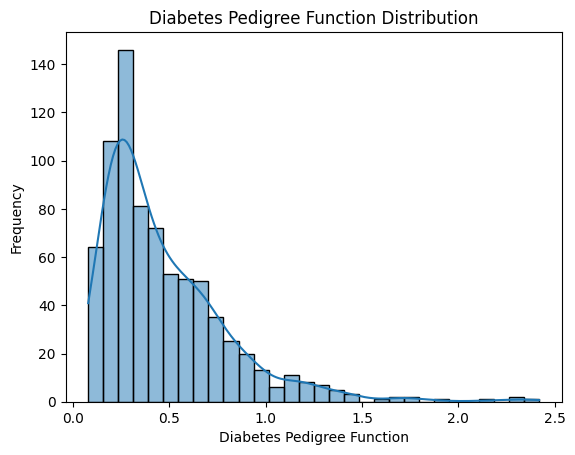

In [12]:
sns.histplot(df['DiabetesPedigreeFunction'], bins=30, kde=True)
plt.title('Diabetes Pedigree Function Distribution')
plt.xlabel('Diabetes Pedigree Function')
plt.ylabel('Frequency')
plt.show()

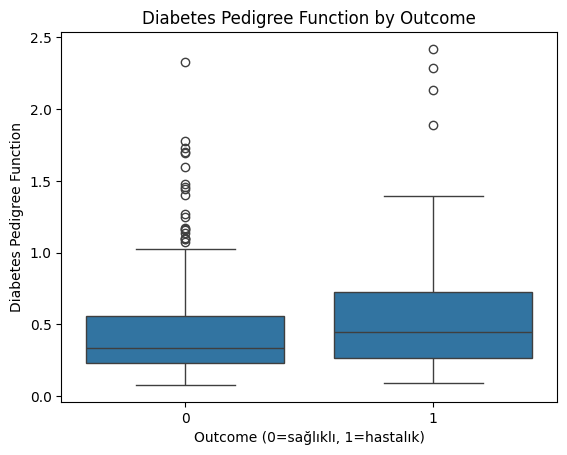

In [13]:
sns.boxplot(x='Outcome', y='DiabetesPedigreeFunction', data=df)
plt.title('Diabetes Pedigree Function by Outcome')
plt.xlabel('Outcome (0=sağlıklı, 1=hastalık)')
plt.ylabel('Diabetes Pedigree Function')
plt.show()

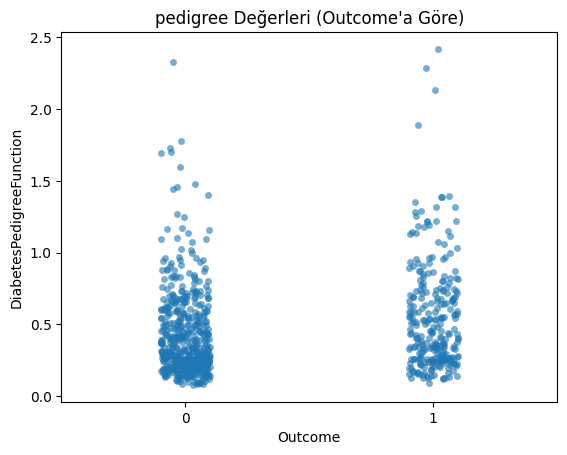

In [14]:
sns.stripplot(x='Outcome', y='DiabetesPedigreeFunction', data=df, jitter=True, alpha=0.6)
plt.title('pedigree Değerleri (Outcome\'a Göre)')
plt.show()

In [15]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15)

In [17]:
columns_to_fill = ['Glucose', 'BloodPressure','SkinThickness', 'Insulin', 'BMI']

In [18]:
# medyanları almak
medians = {}
for col in columns_to_fill:
  median_value = X_train[X_train[col] != 0][col].median()
  medians[col] = median_value # buraya kaydedelim diye
  #print(median_value)
  X_train[col] = X_train[col].replace(0, median_value) # sıfır olanları medyan değeri ile değiştiriyor

for col in columns_to_fill:
  X_test[col] = X_test[col].replace(0, medians[col])

In [19]:
X_train.describe() # pregnency hariç minimumlar değişti

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,3.907166,121.560261,72.612378,29.040717,142.477199,32.448208,0.469948,33.285016
std,3.385438,29.974412,12.165642,8.312217,80.879330,6.862948,0.328516,11.678337
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.084000,21.000000
25%,1.000000,100.000000,64.000000,25.000000,125.000000,27.600000,0.238250,24.000000
50%,3.000000,117.000000,72.000000,29.000000,129.500000,32.300000,0.370500,29.000000
75%,6.000000,139.750000,80.000000,32.000000,130.000000,36.500000,0.630750,40.000000
max,17.000000,199.000000,122.000000,63.000000,680.000000,67.100000,2.420000,81.000000


In [20]:
X_test.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000
mean,3.597403,122.038961,71.487013,29.376623,144.402597,32.483117,0.479565,33.064935
std,3.304818,32.320876,11.813495,10.513035,104.291511,6.946159,0.343303,12.118519
min,0.000000,61.000000,30.000000,7.000000,23.000000,18.400000,0.078000,21.000000
25%,1.000000,95.250000,64.000000,23.250000,108.250000,26.925000,0.254000,24.000000
50%,3.000000,117.000000,72.000000,29.000000,129.500000,32.300000,0.376500,28.000000
75%,5.750000,142.750000,80.000000,33.750000,129.500000,36.950000,0.603750,41.000000
max,13.000000,197.000000,106.000000,99.000000,846.000000,55.000000,2.329000,69.000000


In [21]:
#bu tarz datalarda (ağaç gerektiren) scaler kullanmaya gerek yok(regresyonlarda yapmak daha mantıklı)


In [22]:
#defterde dursun diye yapalım (sonuçta bir şey değiştirmeyecektir )
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [29]:
ada = AdaBoostClassifier()
ada.fit(X_train, y_train)
y_pred = ada.predict(X_test)

In [30]:
print(classification_report(y_test, y_pred))
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.81      0.82       108
           1       0.58      0.63      0.60        46

    accuracy                           0.75       154
   macro avg       0.71      0.72      0.71       154
weighted avg       0.76      0.75      0.76       154

0.7532467532467533
[[87 21]
 [17 29]]


In [31]:
# Hyperparameter tuning

In [32]:
from sklearn.model_selection import GridSearchCV

In [33]:
adaboost_param = {
    "n_estimators":[50, 70, 100, 120, 150, 200],
    "learning_rate":[0.001, 0.01, 0.1, 1, 10]
}
# çok parametremiz yok zaten en önemlisi estimator

In [35]:
grid = GridSearchCV(estimator=AdaBoostClassifier(), param_grid= adaboost_param, cv=3, verbose=1, n_jobs=-1)

In [36]:
grid.fit(X_train, y_train)

Fitting 3 folds for each of 30 candidates, totalling 90 fits


GridSearchCV(cv=3, estimator=AdaBoostClassifier(), n_jobs=-1,
             param_grid={'learning_rate': [0.001, 0.01, 0.1, 1, 10],
                         'n_estimators': [50, 70, 100, 120, 150, 200]},
             verbose=1)

In [38]:
grid.best_params_ #bunları kullanalım

{'learning_rate': 1, 'n_estimators': 200}

In [39]:
ada = AdaBoostClassifier(learning_rate= 1, n_estimators= 100)

In [40]:
ada.fit(X_train, y_train)
y_pred = ada.predict(X_test)
print(classification_report(y_test, y_pred))
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.81      0.83       108
           1       0.61      0.67      0.64        46

    accuracy                           0.77       154
   macro avg       0.73      0.74      0.74       154
weighted avg       0.78      0.77      0.78       154

0.7727272727272727
[[88 20]
 [15 31]]


In [41]:
# ödev olarak
# skinthickness ve insulini drop ederek yapmayı dene
# diğer algoritmaları deneyerek yapmayı dene svc, naive bayes vs.